In [1]:
#02_exploratory_analysis

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figure directory: {FIGURE_DIR}")

Project root: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization
Figure directory: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization\reports\figures


In [3]:
from src.data.io import (
    load_m5_calendar,
    load_m5_prices,
    load_m5_sales,
    load_synthetic_retail_data,
)


retail = load_synthetic_retail_data()

m5_calendar = load_m5_calendar()
m5_prices_sample = load_m5_prices(nrows=100_000)
m5_sales_sample = load_m5_sales(nrows=100)

retail["date"] = pd.to_datetime(retail["date"])
m5_calendar["date"] = pd.to_datetime(m5_calendar["date"])

print(f"Synthetic retail: {retail.shape}")
print(f"M5 calendar: {m5_calendar.shape}")
print(f"M5 price sample: {m5_prices_sample.shape}")
print(f"M5 sales sample: {m5_sales_sample.shape}")

Synthetic retail: (18300, 29)
M5 calendar: (1969, 14)
M5 price sample: (100000, 4)
M5 sales sample: (100, 1919)


In [4]:
promotion_rows = retail["promotion_flag"].eq(1)

kpi_summary = pd.Series(
    {
        "Number of records": len(retail),
        "Total units sold": retail["units_sold"].sum(),
        "Total revenue": retail["revenue"].sum(),
        "Total gross profit": retail["gross_profit"].sum(),
        "Average selling price": retail["selling_price"].mean(),
        "Average units per observation": retail["units_sold"].mean(),
        "Promotion rate (%)": retail["promotion_flag"].mean() * 100,
        "Average promotional discount (%)": (
            retail.loc[promotion_rows, "discount_pct"].mean() * 100
        ),
        "Stockout rate (%)": retail["stockout_flag"].mean() * 100,
        "Overall gross margin (%)": (
            retail["gross_profit"].sum()
            / retail["revenue"].sum()
            * 100
        ),
    },
    name="Value",
)

kpi_summary.to_frame()

,Value
Number of records,"18,300.00"
Total units sold,"640,344.00"
Total revenue,"4,260,956.48"
Total gross profit,"2,168,163.81"
Average selling price,7.57
Average units per observation,34.99
Promotion rate (%),16.01
Average promotional discount (%),13.89
Stockout rate (%),22.01
Overall gross margin (%),50.88


In [5]:
daily_performance = (
    retail.groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
    )
    .sort_values("date")
)

daily_performance["revenue_28_day_average"] = (
    daily_performance["revenue"]
    .rolling(window=28, min_periods=1)
    .mean()
)

daily_performance.head()

,date,units_sold,revenue,gross_profit,revenue_28_day_average
0,2024-01-01,2323,"15,900.43","7,764.84","15,900.43"
1,2024-01-02,1686,"11,156.07","5,599.20","13,528.25"
2,2024-01-03,1554,"10,906.61","5,676.03","12,654.37"
3,2024-01-04,1389,"9,373.62","4,860.96","11,834.18"
4,2024-01-05,1662,"11,534.75","5,938.60","11,774.30"


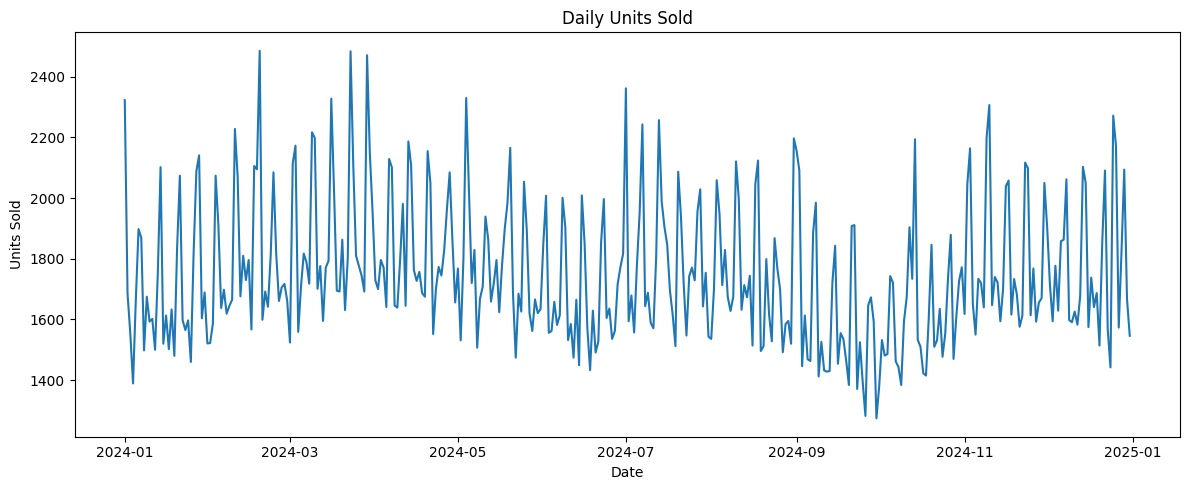

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(
    daily_performance["date"],
    daily_performance["units_sold"],
)
plt.title("Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "daily_units_sold.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

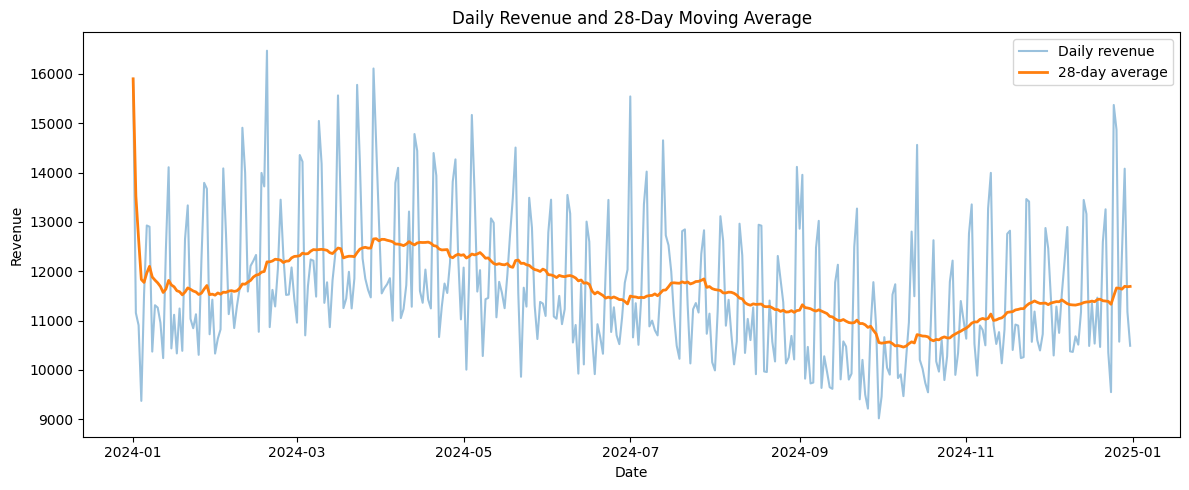

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(
    daily_performance["date"],
    daily_performance["revenue"],
    alpha=0.45,
    label="Daily revenue",
)
plt.plot(
    daily_performance["date"],
    daily_performance["revenue_28_day_average"],
    linewidth=2,
    label="28-day average",
)
plt.title("Daily Revenue and 28-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "daily_revenue_trend.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

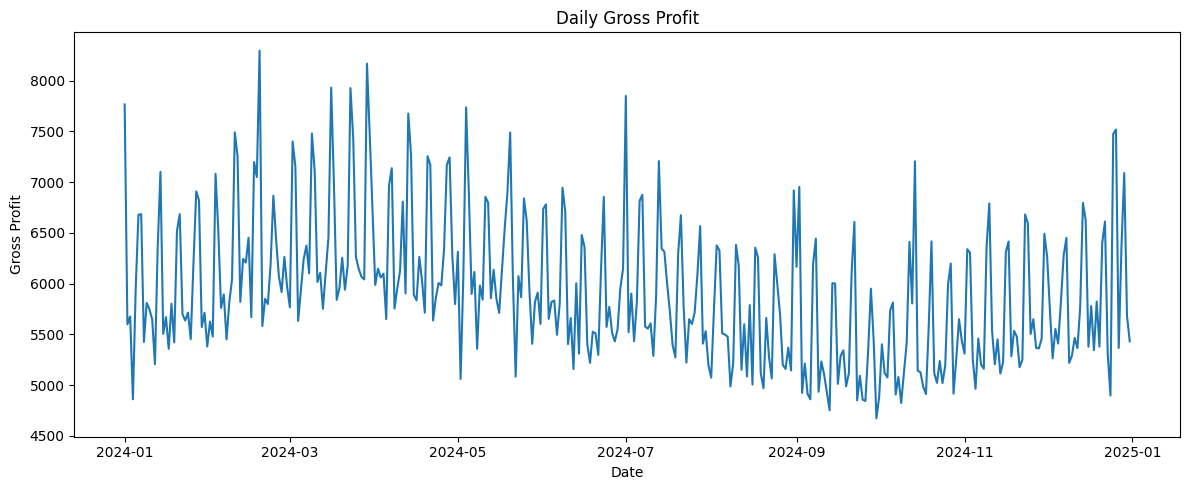

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(
    daily_performance["date"],
    daily_performance["gross_profit"],
)
plt.title("Daily Gross Profit")
plt.xlabel("Date")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "daily_gross_profit.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [9]:
category_summary = (
    retail.groupby("category", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        average_selling_price=("selling_price", "mean"),
        promotion_rate=("promotion_flag", "mean"),
        stockout_rate=("stockout_flag", "mean"),
    )
)

category_summary["gross_margin_pct"] = (
    category_summary["gross_profit"]
    / category_summary["revenue"]
    * 100
)

category_summary["promotion_rate_pct"] = (
    category_summary["promotion_rate"] * 100
)

category_summary["stockout_rate_pct"] = (
    category_summary["stockout_rate"] * 100
)

category_summary = category_summary.sort_values(
    "revenue",
    ascending=False,
)

category_summary

,category,units_sold,revenue,gross_profit,average_selling_price,promotion_rate,stockout_rate,gross_margin_pct,promotion_rate_pct,stockout_rate_pct
1,Grocery,248628,"1,366,086.19","712,697.05",6.03,0.15,0.21,52.17,15.10,20.95
0,Beverages,216703,"1,365,154.70","696,654.11",6.83,0.17,0.22,51.03,17.27,22.37
3,Personal Care,95082,"768,547.33","394,623.07",8.56,0.16,0.22,51.35,15.63,22.46
2,Household,79931,"761,168.26","364,189.58",10.01,0.16,0.23,47.85,15.87,22.62


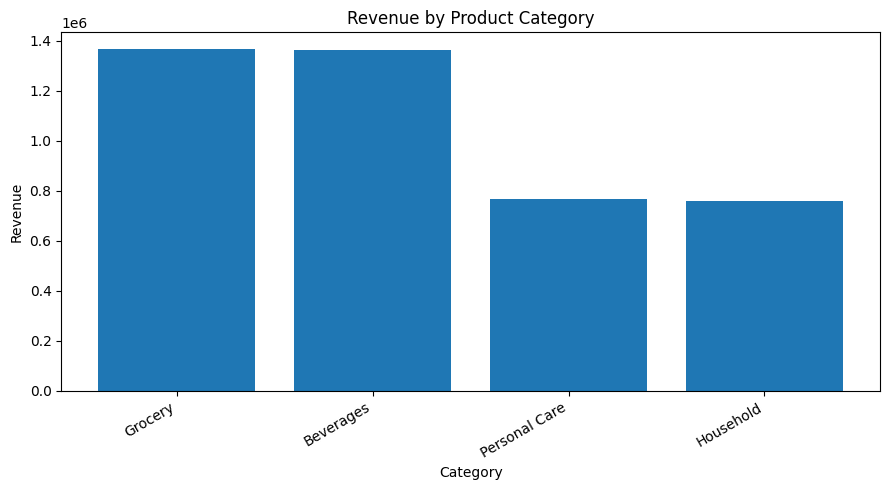

In [10]:
plt.figure(figsize=(9, 5))
plt.bar(
    category_summary["category"],
    category_summary["revenue"],
)
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "revenue_by_category.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [11]:
store_summary = (
    retail.groupby(
        ["store_id", "region"],
        as_index=False,
    )
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        average_customer_traffic=(
            "customer_traffic",
            "mean",
        ),
        stockout_rate=("stockout_flag", "mean"),
    )
)

store_summary["gross_margin_pct"] = (
    store_summary["gross_profit"]
    / store_summary["revenue"]
    * 100
)

store_summary["stockout_rate_pct"] = (
    store_summary["stockout_rate"] * 100
)

store_summary = store_summary.sort_values(
    "revenue",
    ascending=False,
)

store_summary

,store_id,region,units_sold,revenue,gross_profit,average_customer_traffic,stockout_rate,gross_margin_pct,stockout_rate_pct
2,S003,Central,160144,"1,065,073.82","541,168.98","1,065.61",0.22,50.81,21.56
0,S001,West,140912,"937,822.57","478,224.84",968.75,0.21,50.99,20.74
3,S004,East,122154,"812,254.80","412,493.05",879.95,0.23,50.78,22.73
1,S002,West,113456,"754,075.04","383,222.83",842.30,0.23,50.82,22.79
4,S005,East,103678,"691,730.25","353,054.11",797.05,0.22,51.04,22.24


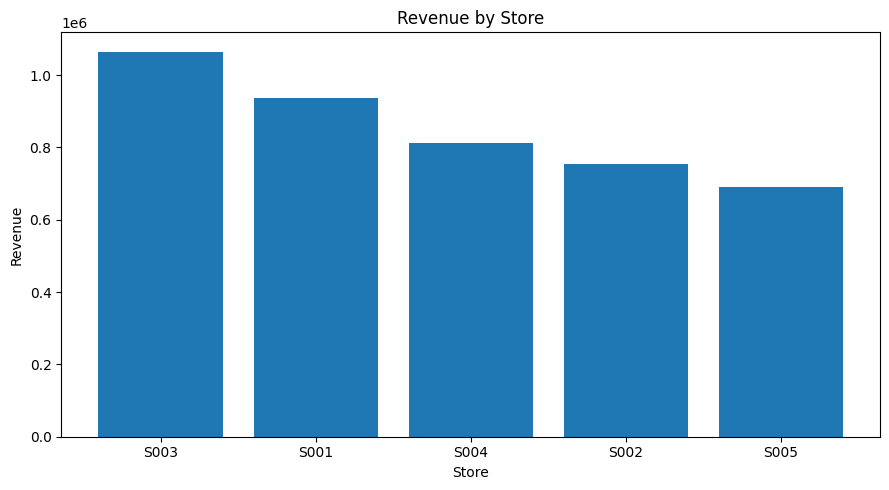

In [12]:
plt.figure(figsize=(9, 5))
plt.bar(
    store_summary["store_id"],
    store_summary["revenue"],
)
plt.title("Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "revenue_by_store.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [13]:
promotion_summary = (
    retail.groupby(
        ["promotion_flag", "promotion_type"],
        as_index=False,
    )
    .agg(
        observations=("units_sold", "size"),
        average_units_sold=("units_sold", "mean"),
        average_selling_price=("selling_price", "mean"),
        average_discount=("discount_pct", "mean"),
        total_revenue=("revenue", "sum"),
        total_gross_profit=("gross_profit", "sum"),
    )
)

promotion_summary["average_discount_pct"] = (
    promotion_summary["average_discount"] * 100
)

promotion_summary

,promotion_flag,promotion_type,observations,average_units_sold,average_selling_price,average_discount,total_revenue,total_gross_profit,average_discount_pct
0,0,none,15370,30.77,7.75,0.00,"3,266,966.35","1,724,870.91",0.00
1,1,bundle_offer,580,51.86,6.72,0.12,"180,833.22","84,095.83",11.61
2,1,feature_display,738,52.40,7.20,0.08,"246,278.23","120,478.58",7.63
3,1,percentage_discount,1612,61.19,6.40,0.18,"566,878.68","238,718.49",17.58


In [14]:
promotion_comparison = (
    retail.groupby("promotion_flag", as_index=False)
    .agg(
        average_units_sold=("units_sold", "mean"),
        average_revenue=("revenue", "mean"),
        average_gross_profit=("gross_profit", "mean"),
    )
)

promotion_comparison["promotion_status"] = (
    promotion_comparison["promotion_flag"]
    .map({0: "No Promotion", 1: "Promotion"})
)

promotion_comparison

,promotion_flag,average_units_sold,average_revenue,average_gross_profit,promotion_status
0,0,30.77,212.55,112.22,No Promotion
1,1,57.13,339.25,151.29,Promotion


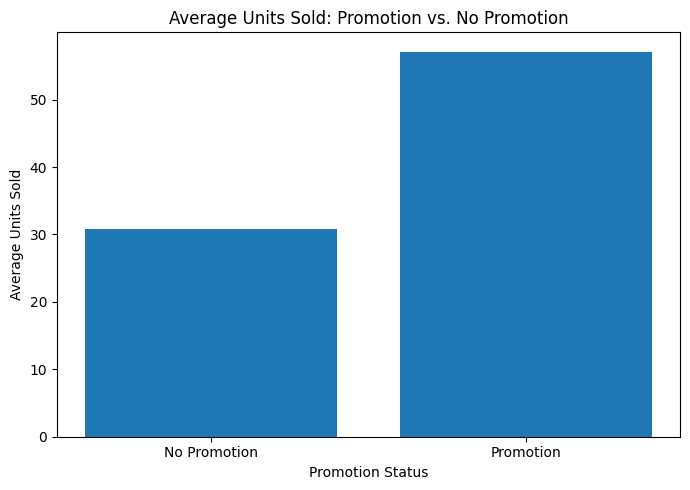

In [15]:
plt.figure(figsize=(7, 5))
plt.bar(
    promotion_comparison["promotion_status"],
    promotion_comparison["average_units_sold"],
)
plt.title("Average Units Sold: Promotion vs. No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "promotion_units_comparison.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

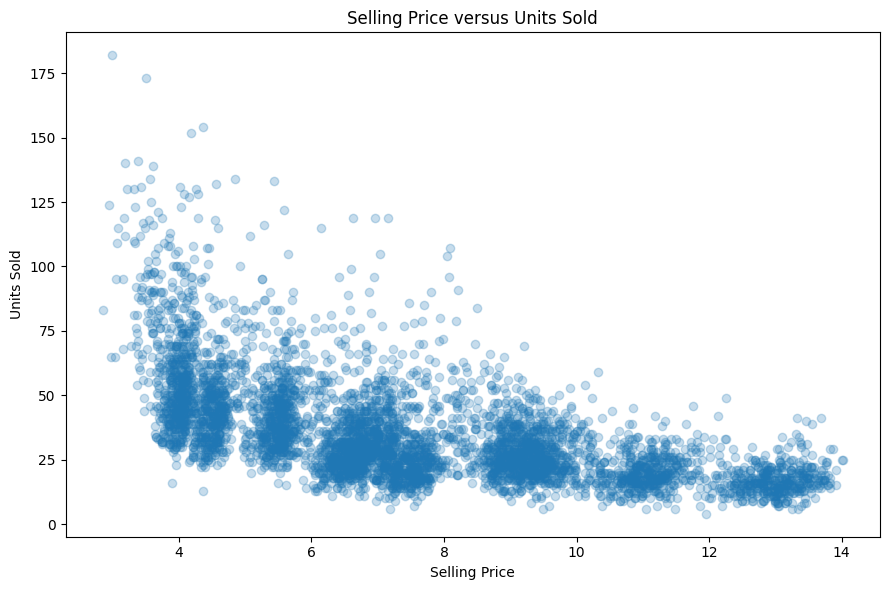

In [16]:
plot_sample = retail.sample(
    n=min(5_000, len(retail)),
    random_state=42,
)

plt.figure(figsize=(9, 6))
plt.scatter(
    plot_sample["selling_price"],
    plot_sample["units_sold"],
    alpha=0.25,
)
plt.title("Selling Price versus Units Sold")
plt.xlabel("Selling Price")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "price_vs_units_sold.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [17]:
product_price_correlations = pd.DataFrame(
    [
        {
            "product_id": product_id,
            "price_units_correlation": group[
                "selling_price"
            ].corr(group["units_sold"]),
        }
        for product_id, group in retail.groupby(
            "product_id"
        )
    ]
).sort_values("price_units_correlation")

product_price_correlations

,product_id,price_units_correlation
2,P003,-0.62
5,P006,-0.58
1,P002,-0.57
0,P001,-0.52
4,P005,-0.50
7,P008,-0.49
9,P010,-0.47
3,P004,-0.42
6,P007,-0.41
8,P009,-0.41


In [18]:
discount_analysis = retail.copy()

discount_analysis["discount_band"] = pd.cut(
    discount_analysis["discount_pct"],
    bins=[-0.001, 0.001, 0.10, 0.15, 0.20, 1.00],
    labels=[
        "No discount",
        "Up to 10%",
        "10% to 15%",
        "15% to 20%",
        "Above 20%",
    ],
    include_lowest=True,
)

discount_summary = (
    discount_analysis.groupby(
        "discount_band",
        observed=False,
        as_index=False,
    )
    .agg(
        observations=("units_sold", "size"),
        average_units_sold=("units_sold", "mean"),
        average_revenue=("revenue", "mean"),
        average_gross_profit=("gross_profit", "mean"),
    )
)

discount_summary

,discount_band,observations,average_units_sold,average_revenue,average_gross_profit
0,No discount,15370,30.77,212.55,112.22
1,Up to 10%,1329,51.08,322.61,156.39
2,10% to 15%,772,55.93,329.98,148.45
3,15% to 20%,426,64.50,365.15,149.81
4,Above 20%,403,71.60,384.47,141.51


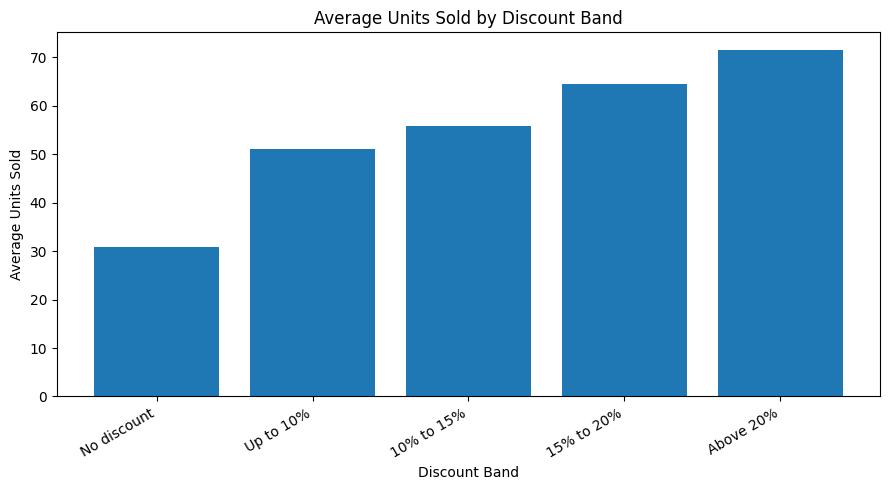

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(
    discount_summary["discount_band"].astype(str),
    discount_summary["average_units_sold"],
)
plt.title("Average Units Sold by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "units_by_discount_band.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [20]:
stockout_summary = (
    retail.groupby("category", as_index=False)
    .agg(
        observations=("stockout_flag", "size"),
        stockout_records=("stockout_flag", "sum"),
        stockout_rate=("stockout_flag", "mean"),
        average_inventory=("inventory_level", "mean"),
        average_units_sold=("units_sold", "mean"),
    )
)

stockout_summary["stockout_rate_pct"] = (
    stockout_summary["stockout_rate"] * 100
)

stockout_summary = stockout_summary.sort_values(
    "stockout_rate_pct",
    ascending=False,
)

stockout_summary

,category,observations,stockout_records,stockout_rate,average_inventory,average_units_sold,stockout_rate_pct
2,Household,3660,828,0.23,27.36,21.84,22.62
3,Personal Care,3660,822,0.22,32.50,25.98,22.46
0,Beverages,5490,1228,0.22,48.94,39.47,22.37
1,Grocery,5490,1150,0.21,56.17,45.29,20.95


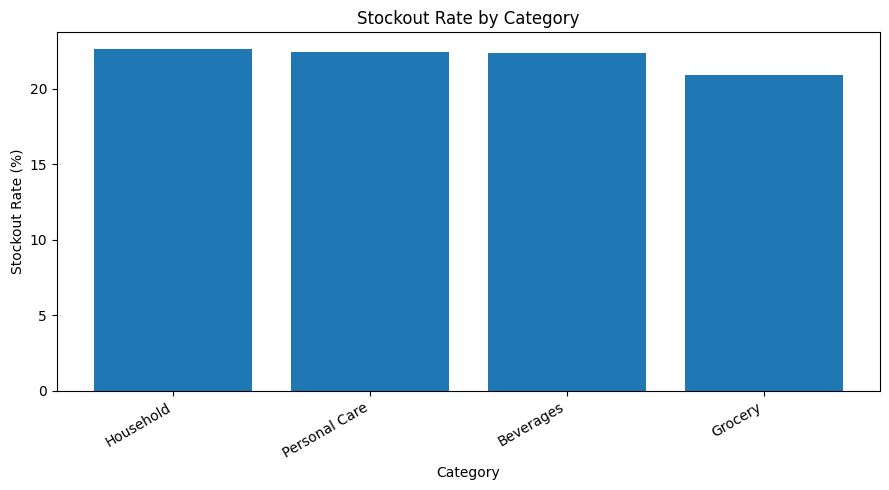

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(
    stockout_summary["category"],
    stockout_summary["stockout_rate_pct"],
)
plt.title("Stockout Rate by Category")
plt.xlabel("Category")
plt.ylabel("Stockout Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "stockout_rate_by_category.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [22]:
m5_id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
]

m5_day_columns = [
    column
    for column in m5_sales_sample.columns
    if column.startswith("d_")
]

m5_sales_long = m5_sales_sample.melt(
    id_vars=m5_id_columns,
    value_vars=m5_day_columns,
    var_name="d",
    value_name="units_sold",
)

m5_sales_long = m5_sales_long.merge(
    m5_calendar[["d", "date"]],
    on="d",
    how="left",
)

m5_daily_sales = (
    m5_sales_long.groupby("date", as_index=False)
    .agg(units_sold=("units_sold", "sum"))
    .sort_values("date")
)

m5_daily_sales["rolling_28_day_units"] = (
    m5_daily_sales["units_sold"]
    .rolling(window=28, min_periods=1)
    .mean()
)

m5_daily_sales.head()

,date,units_sold,rolling_28_day_units
0,2011-01-29,98,98.00
1,2011-01-30,61,79.50
2,2011-01-31,64,74.33
3,2011-02-01,74,74.25
4,2011-02-02,55,70.40


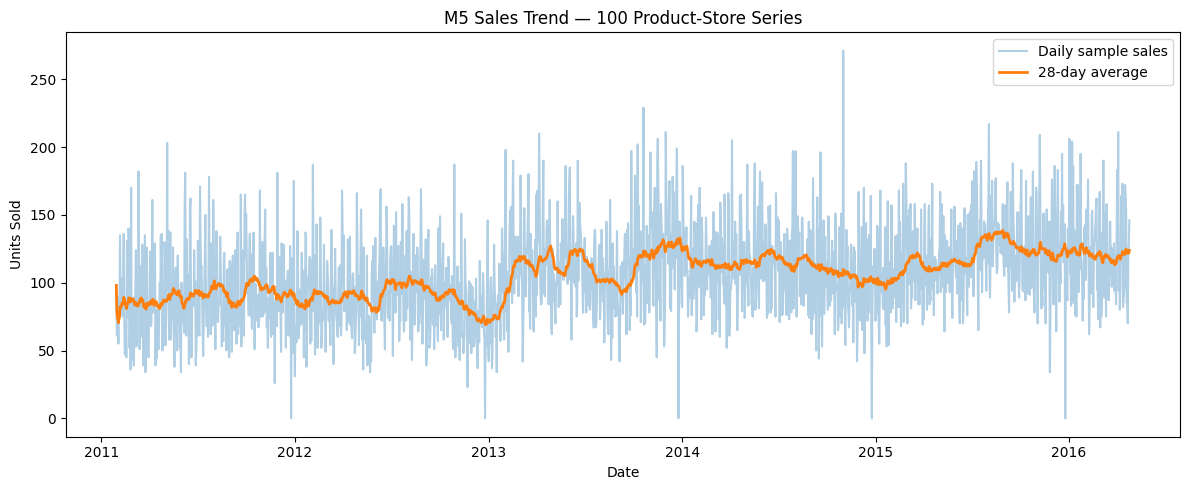

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(
    m5_daily_sales["date"],
    m5_daily_sales["units_sold"],
    alpha=0.35,
    label="Daily sample sales",
)
plt.plot(
    m5_daily_sales["date"],
    m5_daily_sales["rolling_28_day_units"],
    linewidth=2,
    label="28-day average",
)
plt.title("M5 Sales Trend — 100 Product-Store Series")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "m5_sample_sales_trend.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [24]:
m5_prices_sample["sell_price"].describe().to_frame(
    name="sell_price"
)

,sell_price
count,"100,000.00"
mean,6.13
std,5.17
min,0.10
25%,2.08
50%,4.88
75%,8.77
max,30.98


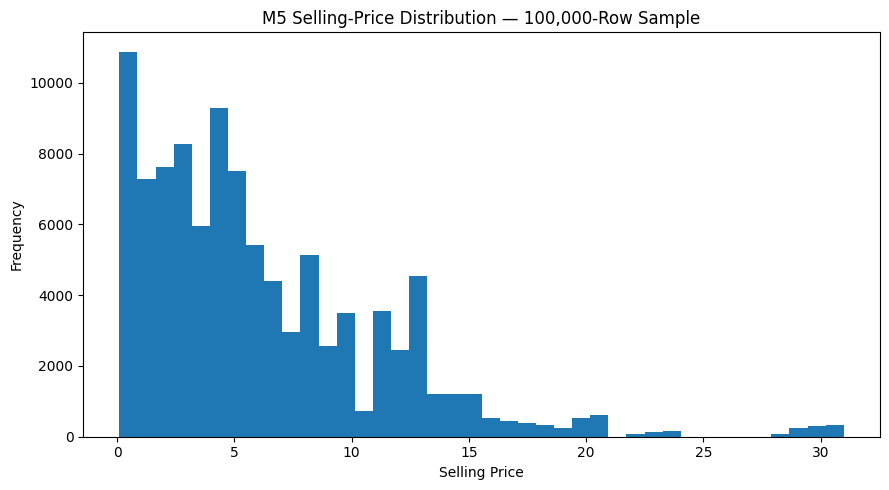

In [25]:
plt.figure(figsize=(9, 5))
plt.hist(
    m5_prices_sample["sell_price"].dropna(),
    bins=40,
)
plt.title("M5 Selling-Price Distribution — 100,000-Row Sample")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "m5_price_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Exploratory Findings

- Sales, revenue, and gross profit vary over time because of seasonality, weekends, holidays, promotions, and customer traffic.
- Revenue and profitability differ across stores, regions, products, and categories.
- Promotional observations generally show different demand and pricing patterns from non-promotional observations.
- Promotion comparisons are descriptive and may be affected by promotion targeting and selection bias.
- Selling price and units sold generally have an inverse relationship, although the strength differs by product.
- Larger discounts can increase average demand but may reduce gross profit per transaction.
- Stockouts create inventory constraints that may suppress observed sales.
- The M5 sample demonstrates strong time variation and supports later demand-forecasting analysis.
- Formal price elasticity, causal promotion effects, forecasting, and optimization will be developed in later notebooks.